# 05 Evaluate AE Scores and Thresholds

Compute reconstruction scores for the trained convolutional autoencoder, select thresholds only on validation data, and evaluate the held-out test split with frozen thresholds.


In [1]:
from pathlib import Path
import json
import torch

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()
MANIFEST_PATH = REPO_ROOT / 'reports' / 'manifests' / 'broach_dataset_split_seed42.csv'

MODEL_PATH = REPO_ROOT / "models" / "ae_bn16_broach_dataset_PyTorch_20260709.pth"
SCORE_DIR = REPO_ROOT / 'reports' / 'scores'
THRESHOLD_DIR = REPO_ROOT / 'reports' / 'thresholds'
SCORE_DIR = REPO_ROOT / 'reports' / 'scores'
TABLE_DIR = REPO_ROOT / 'reports' / 'tables'

DATA_ROOT = REPO_ROOT / "data/03_broach_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

METRICS_PATH = OUTPUT_DIR / "ae_metrics.csv"

In [3]:
class Autoencoder(torch.nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=2, stride=2),

            torch.nn.Conv2d(4, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=(2, 3), stride=(2, 3)),

            torch.nn.Conv2d(8, 12, kernel_size=3, padding=1),
            torch.nn.ReLU()
        )

        self.flatten = torch.nn.Flatten()

        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(12 * 25 * 25, 16),
            torch.nn.ReLU()
        )

        # Decoder
        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(16, 12 * 25 * 25),
            torch.nn.ReLU()
        )

        self.decoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(12, 12, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 3), mode='nearest'),

            torch.nn.Conv2d(12, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 2), mode='nearest'),

            torch.nn.Conv2d(8, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Conv2d(4, 3, kernel_size=3, padding=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder_conv(x)

        x = self.flatten(x)

        latent = self.encoder_fc(x)

        x = self.decoder_fc(latent)

        x = x.view(-1, 12, 25, 25)

        x = self.decoder_conv(x)

        return x

In [4]:
# Load model
model = Autoencoder()

state_dict = torch.load(MODEL_PATH, map_location="cpu")

model.load_state_dict(state_dict)

model.eval()


Autoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 3), stride=(2, 3), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_fc): Sequential(
    (0): Linear(in_features=7500, out_features=16, bias=True)
    (1): ReLU()
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=16, out_features=7500, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=(2.0, 3.0), mode='nearest')
    (3): Conv2d(12, 8, kernel_size=(3, 3), stride=(1, 1), pad

In [5]:
def load_data_from_manifest(data_root: Path, manifest_csv: Path, split: str, target_size=(150, 100)):
    df = pd.read_csv(manifest_csv)
    df_split = df[df["split"] == split].reset_index(drop=True)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        filename = str(row["filename"])
        label = int(row["label"])

        # Dateipfad: train/ bzw. test/ (validation liegt physisch in test/, aber Manifest sagt split=validation)
        folder = data_root / ("test" if split in ["test", "validation"] else "train")
        file_path = folder / filename

        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue

        img = Image.open(file_path).convert("RGB").resize(target_size)
        img = np.array(img).astype("float32") / 255.0

        images.append(img)
        labels.append(label)
        filenames.append(filename)

    return np.array(images), np.array(labels), np.array(filenames)

In [6]:
# Load images

X_val, y_val, f_val = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "validation",
    IMAGE_SIZE
)

X_test, y_test, f_test = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "test",
    IMAGE_SIZE
)

# Keras -> PyTorch
X_val_torch = torch.from_numpy(X_val).permute(0, 3, 1, 2).float()
X_test_torch = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()

print(X_val_torch.shape)
print(X_test_torch.shape)

100%|██████████| 2500/2500 [01:38<00:00, 25.38it/s] 


torch.Size([2500, 3, 100, 150])
torch.Size([2500, 3, 100, 150])


In [7]:
def select_best_f1_threshold(y_true, scores):
    from sklearn.metrics import precision_recall_curve
    import numpy as np

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # Edge case
    if len(thresholds) == 0:
        t = float(np.max(scores))
        return {
            "threshold": t,
            "validation_f1": 0.0,
            "validation_precision": 0.0,
            "validation_recall": 0.0
        }

    # F1 berechnen
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

    best_idx = int(np.nanargmax(f1))

    return {
        "threshold": float(thresholds[best_idx]),
        "validation_f1": float(f1[best_idx]),
        "validation_precision": float(precision[best_idx]),
        "validation_recall": float(recall[best_idx]),
    }

In [8]:
def evaluate_at_threshold(y_true, scores, threshold):
    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix
    )

    y_pred = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "pr_auc": float(average_precision_score(y_true, scores)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# SVE - Segmented Vertical Error

In [9]:
MAX_POOL_WINDOWS = [3, 5, 9, 15, 25, 35, 51, 75, 101]

def vertical_segment_scores(error_map: np.ndarray, n_segments: int, top_k: int):
    width = error_map.shape[2]

    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segment_scores = []
    for left, right in zip(boundaries[:-1], boundaries[1:]):
        if right <= left:
            continue

        segment_scores.append(
            error_map[:, :, left:right, :].mean(axis=(1, 2, 3))
        )

    segment_scores = np.stack(segment_scores, axis=1)

    sve_max = segment_scores.max(axis=1)

    top_k = min(top_k, segment_scores.shape[1])
    sve_topk = np.sort(segment_scores, axis=1)[:, -top_k:].mean(axis=1)

    return sve_max, sve_topk


def max_pool_error_scores(error_map: np.ndarray, pool_size: int, batch_size: int = 64):
    from scipy.ndimage import maximum_filter

    pooled_scores = []
    for start in range(0, len(error_map), batch_size):
        batch = error_map[start:start + batch_size]
        pooled = maximum_filter(
            batch,
            size=(1, pool_size, pool_size, 1),
            mode="nearest"
        )
        pooled_scores.append(pooled.mean(axis=(1, 2, 3)))

    return np.concatenate(pooled_scores)


def score_reconstructions(model, images, batch_size=32):
    # NHWC -> NCHW
    images_torch = (
        torch.from_numpy(images)
        .permute(0, 3, 1, 2)
        .float()
    )
    model.eval()
    recon_batches = []

    with torch.no_grad():
        for start in range(0, len(images_torch), batch_size):
            batch = images_torch[start:start + batch_size]
            recon = model(batch)
            recon_batches.append(
                recon.permute(0, 2, 3, 1).cpu().numpy()
            )

    recon = np.concatenate(recon_batches, axis=0)

    squared_error = (images - recon) ** 2
    absolute_error = np.abs(images - recon)

    sve_max, sve_topk = vertical_segment_scores(
        squared_error,
        n_segments=7,
        top_k=1
    )

    score_data = {
        "global_mse": squared_error.mean(axis=(1, 2, 3)),
        "global_mae": absolute_error.mean(axis=(1, 2, 3)),
        "sve_max": sve_max,
        #"sve_topk": sve_topk,
    }

    for pool_size in MAX_POOL_WINDOWS:
        score_data[f"maxpool_mse_{pool_size}x{pool_size}"] = (
            max_pool_error_scores(
                squared_error,
                pool_size=pool_size,
                batch_size=64
            )
        )

    return pd.DataFrame(score_data)

In [10]:
val_scores = score_reconstructions(model, X_val)
test_scores = score_reconstructions(model, X_test)

# Evaluate Metrics

In [11]:
# --- val: Score DataFrame bauen inkl. metadata ---
val_df = val_scores.copy()
val_df["filename"] = f_val
val_df["label"] = y_val
val_df["split"] = "validation"

# --- test: Score DataFrame bauen inkl. metadata ---
test_df = test_scores.copy()
test_df["filename"] = f_test
test_df["label"] = y_test
test_df["split"] = "test"

# --- Speichere val_scores + test_scores als CSV ---
all_scores = pd.concat([val_df, test_df], ignore_index=True)
SCORES_PATH = SCORE_DIR / 'ae_scores_broach_dataset.csv'
all_scores.to_csv(SCORES_PATH, index=False)
print(f'Wrote {SCORES_PATH}')

score_columns = [
    "global_mse",
    "global_mae",
    "sve_max",
    #"sve_topk",
    *[f"maxpool_mse_{pool_size}x{pool_size}" for pool_size in MAX_POOL_WINDOWS],
]

results = []
thresholds = {}

for score_name in score_columns:
    # --- Threshold (Validation!)
    selected = select_best_f1_threshold(
        y_val,
        val_scores[score_name].values
    )
    threshold = selected["threshold"]
    thresholds[score_name] = selected  

    # --- Test Evaluation ---
    test_metrics = evaluate_at_threshold(
        y_test,
        test_scores[score_name].values,
        threshold
    )
    results.append({
        "dataset": 'broach_dataset',  
        "method": 'cnn_ae',      
        "score": score_name,
        "threshold": threshold,
        **test_metrics
    })

THRESHOLD_PATH = THRESHOLD_DIR / 'ae_thresholds_broach_dataset.json'
with THRESHOLD_PATH.open('w') as f:
    json.dump(thresholds, f, indent=2)
print(f'Wrote {THRESHOLD_PATH}')

# --- Speichere Metriken als CSV ---
METRICS_PATH = TABLE_DIR / 'metrics_broach_dataset_ae.csv'
pd.DataFrame(results).to_csv(METRICS_PATH, index=False)
print(f'Wrote {METRICS_PATH}')

# Ausgabe für die Notebook-Zelle
results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results_df

Wrote C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\scores\ae_scores_broach_dataset.csv
Wrote C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\thresholds\ae_thresholds_broach_dataset.json
Wrote C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\tables\metrics_broach_dataset_ae.csv


,dataset,method,score,threshold,pr_auc,f1,precision,recall,tn,fp,fn,tp
0,broach_dataset,cnn_ae,sve_max,0.003109,0.979270,0.850000,0.944444,0.772727,2477,1,5,17
1,broach_dataset,cnn_ae,maxpool_mse_101x101,0.145790,0.941244,0.625000,1.000000,0.454545,2478,0,12,10
2,broach_dataset,cnn_ae,maxpool_mse_25x25,0.029332,0.918871,0.871795,1.000000,0.772727,2478,0,5,17
3,broach_dataset,cnn_ae,maxpool_mse_35x35,0.042229,0.916222,0.842105,1.000000,0.727273,2478,0,6,16
4,broach_dataset,cnn_ae,maxpool_mse_15x15,0.016754,0.913336,0.842105,1.000000,0.727273,2478,0,6,16
5,broach_dataset,cnn_ae,maxpool_mse_9x9,0.009615,0.908770,0.842105,1.000000,0.727273,2478,0,6,16
6,broach_dataset,cnn_ae,maxpool_mse_51x51,0.064112,0.896715,0.820513,0.941176,0.727273,2477,1,6,16
7,broach_dataset,cnn_ae,maxpool_mse_75x75,0.101274,0.830715,0.742857,1.000000,0.590909,2478,0,9,13
8,broach_dataset,cnn_ae,maxpool_mse_5x5,0.005449,0.795487,0.742857,1.000000,0.590909,2478,0,9,13
9,broach_dataset,cnn_ae,maxpool_mse_3x3,0.003261,0.710810,0.666667,1.000000,0.500000,2478,0,11,11


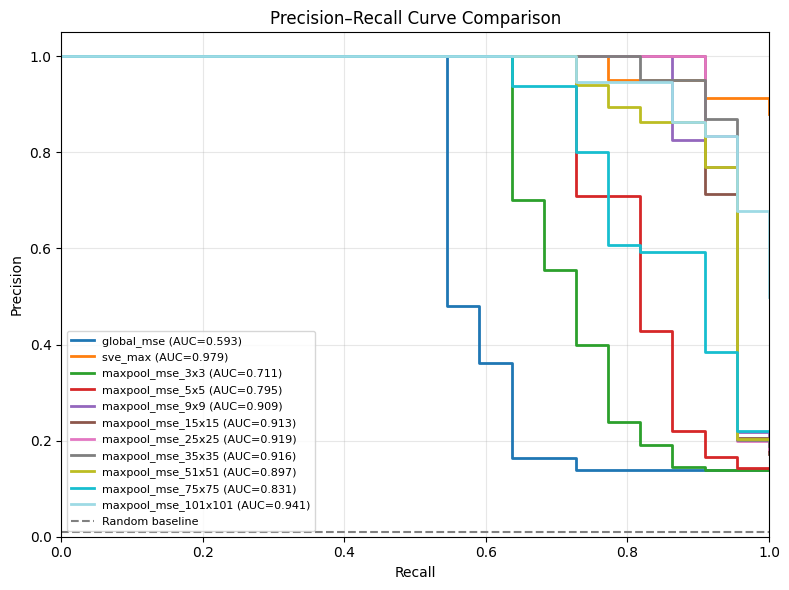

In [12]:
def monotonic_precision_recall_curve(y_true, scores):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    curve = (
        pd.DataFrame({"recall": recall, "precision": precision})
        .groupby("recall", as_index=False)["precision"]
        .max()
        .sort_values("recall")
    )

    recall = curve["recall"].to_numpy()
    precision = curve["precision"].to_numpy()
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    return recall, precision


score_columns = [
    "global_mse",
    "sve_max",
    #"sve_topk",
    *[f"maxpool_mse_{pool_size}x{pool_size}" for pool_size in MAX_POOL_WINDOWS],
]

color_cycle = plt.cm.tab20(np.linspace(0, 1, len(score_columns)))
colors = dict(zip(score_columns, color_cycle))

plt.figure(figsize=(8, 6))

for score in score_columns:
    recall, precision = monotonic_precision_recall_curve(
        y_test,
        test_scores[score].values
    )

    pr_auc = average_precision_score(
        y_test,
        test_scores[score].values
    )

    color = colors[score]

    plt.step(
        recall,
        precision,
        where="post",
        label=f"{score} (AUC={pr_auc:.3f})",
        color=color,
        linewidth=2
    )

baseline = sum(y_test) / len(y_test)
plt.axhline(
    y=baseline,
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Figure with Reduced PR-Curves 

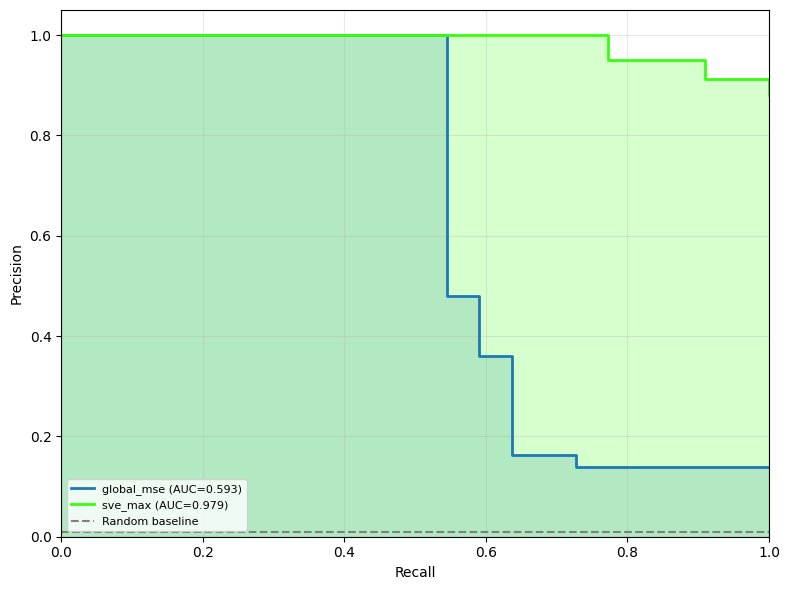

In [13]:
def monotonic_precision_recall_curve(y_true, scores):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    curve = (
        pd.DataFrame({"recall": recall, "precision": precision})
        .groupby("recall", as_index=False)["precision"]
        .max()
        .sort_values("recall")
    )

    recall = curve["recall"].to_numpy()
    precision = curve["precision"].to_numpy()
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    return recall, precision

# ----- nur die gewünschten 5 Metriken -----
score_columns = [
    "global_mse",
    "sve_max",
    #"sve_topk",
    #"maxpool_mse_9x9",
    #"maxpool_mse_101x101",
]

# Farben
color_cycle = plt.cm.tab20(np.linspace(0, 1, len(score_columns)))
colors = {
    "global_mse": "#1f77b4",        # blau
    "sve_max": "#36ff0e",          # orange
    "sve_topk": "#7b2ca0",         # grün
    "maxpool_mse_9x9": "#d62728",  # rot
    "maxpool_mse_101x101": "#9467bd" # lila
}

plt.figure(figsize=(8, 6))

for score in score_columns:
    recall, precision = monotonic_precision_recall_curve(
        y_test,
        test_scores[score].values
    )

    pr_auc = average_precision_score(
        y_test,
        test_scores[score].values
    )

    color = colors[score]

    # Kurve
    plt.step(
        recall,
        precision,
        where="post",
        label=f"{score} (AUC={pr_auc:.3f})",
        color=color,
        linewidth=2
    )

    # transluzente Fläche (unter der Kurve)
    plt.fill_between(
        recall,
        precision,
        step="post",
        alpha=0.2,   # <- Transparenz anpassen
        color=color
    )

# Random baseline
baseline = sum(y_test) / len(y_test)
plt.axhline(
    y=baseline,
    linestyle="--",
    color="gray",
    label="Random baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
#plt.title("Precision–Recall Curve Comparison")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ae_pr_curves_broach_dataset.png", dpi=300)

plt.show()  # bei non-interactive ggf. weglassen

In [14]:
score_labels = {
    "sve_max": "SVE (max segment)",
    #"sve_topk": r"SVE (top-$k$)",
    "global_mse": "Global MSE",
    "global_mae": "Global MAE",
}

latex_lines = [
    r"\begin{table}[H]",
    r"\centering",
    r"\caption{Detection performance of different anomaly scoring methods on the test set.}",
    r"\begin{tabular}{lcccc}",
    r"\hline",
    r"Method & PR-AUC & F1-score & Precision & Recall \\",
    r"\hline",
]

for _, row in results_df.iterrows():

    # Nur die Methoden aus der Publikation übernehmen
    if row["score"] not in score_labels:
        continue

    latex_lines.append(
        f"{score_labels[row['score']]} & "
        f"{row['pr_auc']:.3f} & "
        f"{row['f1']:.3f} & "
        f"{row['precision']:.3f} & "
        f"{row['recall']:.3f} \\\\"
    )

latex_lines.extend([
    r"\hline",
    r"\end{tabular}",
    r"\label{tab:detection_performance}",
    r"\end{table}",
])

latex_code = "\n".join(latex_lines)

LATEX_PATH = TABLE_DIR / "detection_performance_ae.tex"
LATEX_PATH.write_text(latex_code, encoding="utf-8")

print(f"Wrote {LATEX_PATH}")


Wrote C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\tables\detection_performance_ae.tex
